In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import average_precision_score

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

# Module A:資料載入與防漏特徵工程

匯入資料

In [2]:
FILE = "./WB_Machine_Error_Event_0722_0728.xlsx"
df = pd.read_excel(FILE)

RUN_KEYS = ["step_id", "lot_id", "equip_type", "equip_id", "recipe_id", "device_name"]
LOT_KEYS = ["lot_id", "step_id"]          # 分析單位：一批貨在一個站別

# 分組鍵的 NaN 會讓 groupby / merge 行為不一致
for c in RUN_KEYS + ["location", "floor"]:
    if c in df.columns:
        df[c] = df[c].fillna("__NA__")

df["eventcount"] = df["eventcount"].fillna(0)
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"]   = pd.to_datetime(df["end_time"])

all_events = sorted(df.eventmessage.dropna().unique().tolist())

print(f"原始資料 {df.shape}")
print(f"事件類型 {len(all_events)} 種、批號 {df.lot_id.nunique():,}、"
      f"機台 {df.equip_id.nunique():,}、配方 {df.recipe_id.nunique():,}")

原始資料 (35607, 14)
事件類型 39 種、批號 8,210、機台 2,216、配方 305


In [3]:
# # 對每個 lot × step，檢查 in_qty 的模式
# g = run.groupby(["lot_id","step_id"]).agg(
#     n=("in_qty","size"),
#     in_nunique=("in_qty","nunique"),
#     in_max=("in_qty","max"),
#     in_sum=("in_qty","sum"),
#     ng_max=("ng_qty","max"),
#     ng_sum=("ng_qty","sum"),
#     ng_nunique=("ng_qty","nunique"))
# m = g[g.n > 1].copy()

# # 關鍵檢查：ng 分攤值 × 機台數，是否等於某個整數
# m["ng_implied_total"] = m.ng_max * m.n
# m["is_int"] = np.isclose(m.ng_implied_total, m.ng_implied_total.round(), atol=1e-6)
# print(f"ng_max × n 為整數的比例：{m.loc[m.ng_max>0,'is_int'].mean():.1%}")
# print("  （接近 1.0 → 確認 ng_qty 是總量平均分攤，應用 sum 還原）")

# # in_qty 的模式分類
# m["in_pattern"] = np.select(
#     [m.in_nunique == 1,
#      m.in_nunique == m.n],
#     ["全部相同", "全部不同"], default="部分相同")
# print(f"\nin_qty 模式分布：\n{m.in_pattern.value_counts(normalize=True).round(3).to_string()}")

# # 「部分相同」的案例，重複的那個值佔多少台
# sub = m[m.in_pattern == "部分相同"]
# print(f"\n部分相同的案例數：{len(sub)}")

# # 最關鍵：in_qty 的量級是否合理
# print(f"\nin_max 分布：\n{m.in_max.describe().round(0).to_string()}")
# print(f"\nin_sum 分布：\n{m.in_sum.describe().round(0).to_string()}")

建立run 與 lot兩層資料

In [4]:
# --- run 層級：一個 (站別 × 批號 × 機台 × 配方 × 產品) 一列 ---
run = (df.groupby(RUN_KEYS, as_index=False, dropna=False)
    .agg(start_time  = ("start_time", "min"),
         end_time    = ("end_time", "max"),
         in_qty      = ("in_qty", "max"),      # 同一 run 的多列重複同值
         ng_qty      = ("ng_qty", "max"),
         location    = ("location", "first"),
         floor       = ("floor", "first"),
         total_event = ("eventcount", "sum")))
run["lot_key"] = run.lot_id.astype(str) + "|" + run.step_id.astype(str)
print(f"run 數 {len(run):,}")

# --- 聚合方式：依資料診斷結論寫死 ---
#   in_qty：同 lot×step 內「全部不同」佔 66.9% → 各機台實際分配量 → sum
#   ng_qty：ng_max × n 為整數佔 90.8%          → 總量平均分攤     → sum
IN_QTY_AGG = "sum"
NG_QTY_AGG = "sum"

# --- 事件計數（僅供事後分析，不進預測模型）---
ev_lot = (df.assign(lot_key=df.lot_id.astype(str) + "|" + df.step_id.astype(str))
    .dropna(subset=["eventmessage"])
    .groupby(["lot_key", "eventmessage"], as_index=False)["eventcount"].sum()
    .pivot_table(index="lot_key", columns="eventmessage",
                 values="eventcount", aggfunc="sum", fill_value=0))

# --- lot 層級：分析單位 ---
lot = (run.groupby(LOT_KEYS, as_index=False)
    .agg(lot_key     = ("lot_key", "first"),
         start_time  = ("start_time", "min"),
         end_time    = ("end_time", "max"),
         recipe_id   = ("recipe_id", "first"),
         device_name = ("device_name", "first"),
         equip_type  = ("equip_type", "first"),
         floor       = ("floor", "first"),
         location    = ("location", "first"),
         in_qty      = ("in_qty", IN_QTY_AGG),
         ng_qty      = ("ng_qty", NG_QTY_AGG),
         n_runs      = ("lot_id", "size"),
         n_machines  = ("equip_id", "nunique"),
         total_event = ("total_event", "sum")))

lot = lot.merge(ev_lot.reset_index(), on="lot_key", how="left")
lot[all_events] = lot[all_events].fillna(0)

n0 = len(lot)
lot = lot[lot.in_qty > 0].copy()
print(f"排除 in_qty = 0：{n0 - len(lot)} 筆")

# --- 目標與衍生欄位 ---
lot["dur_h"]   = (lot.end_time - lot.start_time).dt.total_seconds() / 3600
lot["ng_rate"] = lot.ng_qty / lot.in_qty
lot["y_bin"]   = (lot.ng_qty > 0).astype(int)
lot["y_qty"]   = lot.ng_qty
lot["date"]    = lot.start_time.dt.date

per_lot_steps        = run.groupby("lot_id").step_id.nunique()
lot["n_steps"]       = lot.lot_id.map(per_lot_steps)
lot["is_multi_step"] = (lot.n_steps > 1).astype(int)

lot = lot.sort_values("start_time").reset_index(drop=True)

print(f"\n分析單位（lot × step）：{len(lot):,}")
print(f"有報廢的比例：{lot.y_bin.mean():.1%}")
print(f"總投入 {lot.in_qty.sum():,.0f}　總報廢 {lot.ng_qty.sum():,.1f}")
print(f"時長中位數：{lot.dur_h.median():.1f} 小時")
print(f"\n每日單位數：\n{lot.groupby('date').size().to_string()}")
print(f"\nng_rate 分位數：\n{lot.ng_rate.quantile([.5,.9,.99,.999,1.0]).round(5).to_string()}")

run 數 17,179
排除 in_qty = 0：0 筆

分析單位（lot × step）：8,394
有報廢的比例：29.2%
總投入 28,722,394　總報廢 13,247.5
時長中位數：18.0 小時

每日單位數：
date
2026-07-09       1
2026-07-10       2
2026-07-11       1
2026-07-13       1
2026-07-16       2
2026-07-17       2
2026-07-18       2
2026-07-19      13
2026-07-20      98
2026-07-21     849
2026-07-22    1245
2026-07-23    1115
2026-07-24    1131
2026-07-25    1219
2026-07-26    1238
2026-07-27    1109
2026-07-28     366

ng_rate 分位數：
0.500    0.00000
0.900    0.00058
0.990    0.00273
0.999    0.00956
1.000    0.34362


因果歷史特徵(as-of邏輯)

In [5]:
def asof_prior(target, hist, key, value, out, min_n=3, fallback=None):
    """
    對 target 每一筆，只採計 hist 中「在本筆 start_time 之前已完工」的同組紀錄。
    以 end_time 嚴格早於 start_time 為判準，避開同批時間戳相同造成的洩漏。
    """
    glob = fallback if fallback is not None else hist[value].mean()
    res_v = np.full(len(target), glob, dtype=float)
    res_n = np.zeros(len(target))
    pos = {k: i for i, k in enumerate(target.index)}

    for gkey, h in hist.groupby(key, sort=False):
        h = h.sort_values("end_time")
        ends, vals = h.end_time.values, h[value].values
        tgt = target[target[key] == gkey]
        for idx, st in zip(tgt.index, tgt.start_time.values):
            m = ends < st
            n = int(m.sum())
            res_n[pos[idx]] = n
            if n >= min_n:
                res_v[pos[idx]] = vals[m].mean()

    target[out] = res_v
    target[out + "_n"] = res_n
    return target

gp, gr = lot.y_bin.mean(), lot.ng_rate.mean()
hist_lot = lot[["lot_key","recipe_id","device_name","equip_type",
                "start_time","end_time","y_bin","ng_rate"]].copy()

lot = asof_prior(lot, hist_lot, "recipe_id",   "y_bin",   "prior_recipe_p",    fallback=gp)
lot = asof_prior(lot, hist_lot, "recipe_id",   "ng_rate", "prior_recipe_rate", fallback=gr)
lot = asof_prior(lot, hist_lot, "device_name", "y_bin",   "prior_device_p",    fallback=gp)
lot = asof_prior(lot, hist_lot, "equip_type",  "y_bin",   "prior_eqtype_p",    fallback=gp)

# --- 機台歷史：以 (機台 × lot_key) 為單位 ---
eq_hist = (run.groupby(["equip_id","lot_key"], as_index=False)
    .agg(start_time=("start_time","min"), end_time=("end_time","max"),
         in_qty=("in_qty","max"), ng_qty=("ng_qty","max")))
eq_hist["y_bin"]   = (eq_hist.ng_qty > 0).astype(int)
eq_hist["ng_rate"] = eq_hist.ng_qty / eq_hist.in_qty.clip(lower=1)

eq_tgt = eq_hist.copy()
eq_tgt = asof_prior(eq_tgt, eq_hist, "equip_id", "y_bin",   "eq_prior_p",    fallback=gp)
eq_tgt = asof_prior(eq_tgt, eq_hist, "equip_id", "ng_rate", "eq_prior_rate", fallback=gr)

eq_agg = eq_tgt.groupby("lot_key")[["eq_prior_p","eq_prior_rate","eq_prior_p_n"]].agg(["mean","max"])
eq_agg.columns = [f"{a}_{b}" for a, b in eq_agg.columns]
lot = lot.merge(eq_agg.reset_index(), on="lot_key", how="left")

no_hist = (eq_tgt.eq_prior_p_n == 0).mean()
USE_EQ_PRIOR = no_hist < 0.5
print(f"機台歷史樣本數中位數 {eq_tgt.eq_prior_p_n.median():.0f}，"
      f"無歷史比例 {no_hist:.1%} → {'納入' if USE_EQ_PRIOR else '排除'}")

機台歷史樣本數中位數 3，無歷史比例 21.4% → 納入


排程特徵與洩漏稽核

In [6]:
# 分派結構（排程時已決定，不構成洩漏）
split = (run.groupby(["lot_key","equip_id"], as_index=False).in_qty.max()
           .groupby("lot_key").in_qty
           .agg(mc_n="size", mc_max="max", mc_sum="sum", mc_std="std"))
split["split_cv"]  = split.mc_std / (split.mc_sum / split.mc_n).replace(0, np.nan)
split["max_share"] = split.mc_max / split.mc_sum.replace(0, np.nan)
lot = lot.merge(split[["split_cv","max_share"]].reset_index(), on="lot_key", how="left")

lot["log_in_qty"] = np.log(lot.in_qty.clip(lower=1))
lot["start_hour"] = lot.start_time.dt.hour
lot["weekday"]    = lot.start_time.dt.weekday
lot["is_night"]   = ((lot.start_hour >= 20) | (lot.start_hour < 8)).astype(int)

FEATURES_NUM = ["log_in_qty","n_runs","n_machines","n_steps","is_multi_step",
                "split_cv","max_share","start_hour","weekday","is_night",
                "prior_recipe_p","prior_recipe_rate","prior_recipe_p_n",
                "prior_device_p","prior_eqtype_p"]
if USE_EQ_PRIOR:
    FEATURES_NUM += ["eq_prior_p_mean","eq_prior_p_max",
                     "eq_prior_rate_mean","eq_prior_rate_max"]
FEATURES_NUM = [c for c in FEATURES_NUM if c in lot.columns]
FEATURES_CAT = ["equip_type","floor","step_id"]

FORBIDDEN = ["ng_qty","y_bin","y_qty","ng_rate","end_time","dur_h","total_event"] + all_events
leak = [c for c in FEATURES_NUM + FEATURES_CAT if c in FORBIDDEN]
assert not leak, f"洩漏欄位：{leak}"

print(f"數值特徵 {len(FEATURES_NUM)}、類別特徵 {len(FEATURES_CAT)}，洩漏稽核通過")
print(f"\n缺值比例：\n{lot[FEATURES_NUM].isna().mean().round(3).sort_values(ascending=False).head(8).to_string()}")

數值特徵 19、類別特徵 3，洩漏稽核通過

缺值比例：
split_cv         0.338
n_runs           0.000
log_in_qty       0.000
n_machines       0.000
n_steps          0.000
is_multi_step    0.000
max_share        0.000
start_hour       0.000


# Module C : Champion-Challenger 與Walk-Forward 驗證

模型與指標定義

In [ ]:
K_PER_DAY = 20

def build_X(tr, te, enc=None, med=None):
    """
    enc / med 為 None 時，以 tr 擬合並回傳；
    傳入既有的 enc / med 則直接沿用，確保欄位一致。
    """
    if enc is None:
        enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=20)
        enc.fit(tr[FEATURES_CAT].astype(str))
    if med is None:
        med = tr[FEATURES_NUM].median()

    def _mk(d):
        C = enc.transform(d[FEATURES_CAT].astype(str))
        N = d[FEATURES_NUM].fillna(med).to_numpy(dtype=np.float64)
        X = np.hstack([N, C])
        return np.nan_to_num(np.ascontiguousarray(X, dtype=np.float64),
                             posinf=0, neginf=0)

    return _mk(tr), _mk(te), enc, med

def m0_random(tr, te):
    return np.random.default_rng(0).random(len(te))

def m1_recipe_prior(tr, te):
    return te["prior_recipe_p"].fillna(tr.y_bin.mean()).values

def m2_logistic(tr, te):
    Xtr, Xte, _, _ = build_X(tr, te)
    mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-9
    m = LogisticRegression(max_iter=3000, class_weight="balanced")
    m.fit((Xtr - mu) / sd, tr.y_bin.to_numpy())
    return m.predict_proba((Xte - mu) / sd)[:, 1]


def m3_gbdt(tr, te):
    import xgboost as xgb
    Xtr, Xte, _, _ = build_X(tr, te)
    ytr = tr.y_bin.to_numpy(dtype=np.int32)
    npos = max(int(ytr.sum()), 1)
    m = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, scale_pos_weight=(len(ytr) - npos) / npos,
        objective="binary:logistic", eval_metric="aucpr",
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=0)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]

MODELS  = {"M0 隨機": m0_random, "M1 配方歷史率": m1_recipe_prior,
           "M2 邏輯迴歸": m2_logistic, "M3 GBDT": m3_gbdt}
CHAMPION = "M1 配方歷史率"

def precision_at_k(y, s, k):
    return y.values[np.argsort(-s)[:k]].mean() if k > 0 else np.nan

def lift_at_k(y, s, k):
    b = y.mean()
    return precision_at_k(y, s, k) / b if b > 0 else np.nan

def loss_capture_at_k(q, s, k):
    tot = q.sum()
    return q.values[np.argsort(-s)[:k]].sum() / tot if tot > 0 else np.nan

Walk-Forward 驗證

In [ ]:
# 只保留批數足夠的日子——批數過少的日子是超長滯留批的殘留，
# 訓練集與測試集都太小，結果純屬雜訊
MIN_LOTS_PER_DAY = 200

day_size = lot.groupby("date").size()
print("每日批數：")
print(day_size.to_string())

valid_days = sorted(day_size[day_size >= MIN_LOTS_PER_DAY].index)
print(f"\n納入的日子（>= {MIN_LOTS_PER_DAY} 批）：{len(valid_days)} 天")
print(f"  {valid_days[0]} ~ {valid_days[-1]}")
MIN_TRAIN_DAYS = 2
records = []

for i in range(MIN_TRAIN_DAYS, len(days)):
    tr = lot[lot.date <  days[i]]
    te = lot[lot.date == days[i]]
    if len(te) < 20 or te.y_bin.sum() < 3 or tr.y_bin.sum() < 10:
        print(f"[skip] {days[i]}：測試 {len(te)} 筆／正樣本 {te.y_bin.sum()}")
        continue
    k = min(K_PER_DAY, len(te))
    for name, fn in MODELS.items():
        try:
            s = np.asarray(fn(tr, te), dtype=float)
        except Exception as e:
            print(f"[skip] {name} @ {days[i]}: {type(e).__name__}: {e}")
            continue
        records.append({"date": days[i], "model": name, "n_test": len(te), "k": k,
                        "base_rate": te.y_bin.mean(),
                        "PR_AUC": average_precision_score(te.y_bin, s),
                        "P_at_K": precision_at_k(te.y_bin, s, k),
                        "Lift_at_K": lift_at_k(te.y_bin, s, k),
                        "LossCap_at_K": loss_capture_at_k(te.y_qty, s, k)})

wf = pd.DataFrame(records)
if wf.empty:
    print("無有效折數——資料期間過短或正樣本不足")
else:
    display(wf.groupby("model")[["base_rate","PR_AUC","P_at_K",
                                 "Lift_at_K","LossCap_at_K"]].mean().round(3))
    print(f"\n有效折數：{wf.date.nunique()}")
    print("\n=== Golden Rule 晉升檢核 ===")
    ch = wf[wf.model == CHAMPION].set_index("date")["P_at_K"]
    for m in MODELS:
        if m in (CHAMPION, "M0 隨機"):
            continue
        a = wf[wf.model == m].set_index("date")["P_at_K"]
        common = a.index.intersection(ch.index)
        if len(common) == 0:
            continue
        win = (a[common] > ch[common]).mean()
        print(f"{m:<14} 勝過 Champion {win:.0%} 的折數 "
              f"→ {'可晉升' if win > 0.6 else '不晉升，維持原模型'}")

,base_rate,PR_AUC,P_at_K,Lift_at_K,LossCap_at_K
model,,,,,
M0 隨機,0.268,0.285,0.292,1.149,0.023
M1 配方歷史率,0.268,0.539,0.750,2.797,0.078
M2 邏輯迴歸,0.268,0.533,0.733,2.754,0.075
M3 GBDT,0.268,0.541,0.808,3.047,0.114



有效折數：6

=== Golden Rule 晉升檢核 ===
M2 邏輯迴歸        勝過 Champion 33% 的折數 → 不晉升，維持原模型
M3 GBDT        勝過 Champion 50% 的折數 → 不晉升，維持原模型


# Module B:風險排序與P1-P4分級

雙模型輸出預期損失


In [9]:
print(xgb.__version__)

3.4.0


In [14]:
import xgboost as xgb

CUT = days[-1]
tr, te = lot[lot.date < CUT].copy(), lot[lot.date == CUT].copy()
print(f"訓練 {len(tr):,}（正樣本 {tr.y_bin.sum()}），預測 {len(te):,}")

# 編碼器以完整訓練集擬合一次，後續全部沿用
Xtr, Xte, ENC, MED = build_X(tr, te)
ytr = tr.y_bin.to_numpy(dtype=np.int32)

assert np.isfinite(Xtr).all() and np.isfinite(Xte).all(), "特徵含 inf/NaN"
assert len(np.unique(ytr)) == 2, "訓練集只有單一類別"
print(f"特徵矩陣 {Xtr.shape}")

npos = max(int(ytr.sum()), 1)
clf = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, scale_pos_weight=(len(ytr) - npos) / npos,
    objective="binary:logistic", eval_metric="aucpr",
    tree_method="hist", n_jobs=-1, verbosity=0, random_state=0)
clf.fit(Xtr, ytr)
p_hat = clf.predict_proba(Xte)[:, 1]

# 損失模型：沿用同一組 ENC / MED，欄位才會對齊
pos = tr[tr.y_bin == 1]
if len(pos) >= 30:
    Xpos, _, _, _ = build_X(pos, te, enc=ENC, med=MED)
    assert Xpos.shape[1] == Xte.shape[1], f"欄位不一致 {Xpos.shape[1]} vs {Xte.shape[1]}"
    ypos = np.log1p(pos.y_qty.to_numpy(dtype=np.float64))
    reg = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        objective="reg:absoluteerror", tree_method="hist",
        n_jobs=-1, verbosity=0, random_state=0)
    reg.fit(Xpos, ypos)
    qty_hat = np.expm1(reg.predict(Xte)).clip(min=0)
else:
    print("正樣本不足，損失模型改用歷史平均")
    qty_hat = np.full(len(te), pos.y_qty.mean() if len(pos) else lot.y_qty.mean())

out = te.copy()
out["p_hat"]    = p_hat
out["qty_hat"]  = qty_hat
out["exp_loss"] = p_hat * qty_hat
out = out.sort_values("exp_loss", ascending=False).reset_index(drop=True)

訓練 8,028（正樣本 2385），預測 366
特徵矩陣 (8028, 39)


特徵重要度

In [19]:
feat_names = FEATURES_NUM + list(ENC.get_feature_names_out(FEATURES_CAT))
assert len(feat_names) == Xtr.shape[1]

imp = (pd.Series(clf.feature_importances_, index=feat_names)
         .sort_values(ascending=False).head(15))
print("=== 特徵重要度（前 15）===")
print(imp.round(4).to_string())

=== 特徵重要度（前 15）===
prior_recipe_p                     0.1025
n_machines                         0.0667
equip_type_IConn Pro Cu            0.0447
equip_type_IConn Pro Cu Plus LA    0.0402
floor_3F                           0.0382
prior_device_p                     0.0353
prior_recipe_rate                  0.0334
floor_2F                           0.0293
max_share                          0.0292
n_runs                             0.0289
equip_type_UTC-5000 NeoCu          0.0256
equip_type_UTC-2000S               0.0252
floor_4F                           0.0241
floor_1F                           0.0238
step_id_A42                        0.0232


P1-P4分級與每日清單

In [15]:
p_hi, loss_hi = out.p_hat.quantile(0.80), out.qty_hat.quantile(0.80)

def grade(r):
    hp, hl = r.p_hat >= p_hi, r.qty_hat >= loss_hi
    if hp and hl:     return "P1 立即調查"
    if hp:            return "P2 排程改善"
    if hl:            return "P3 持續監控"
    return "P4 暫不行動"

out["grade"] = out.apply(grade, axis=1)

print("=== 分級結果 ===")
display(out.groupby("grade").agg(
    批數=("lot_key","size"), 平均機率=("p_hat","mean"),
    平均預估量=("qty_hat","mean"), 實際報廢批=("y_bin","sum"),
    實際命中率=("y_bin","mean"), 實際報廢量=("y_qty","sum")).round(3))

k = min(K_PER_DAY, len(out))
print(f"\n=== 今日 Top {k} 加嚴檢驗清單 ===")
display(out.head(k)[["lot_id","step_id","recipe_id","device_name","in_qty",
                     "n_machines","p_hat","qty_hat","exp_loss","grade"]].round(3))

base = max(out.y_bin.mean(), 1e-9)
print(f"\nPrecision@{k} = {out.head(k).y_bin.mean():.1%}"
      f"（基準 {base:.1%}，Lift {out.head(k).y_bin.mean()/base:.2f}x）")
print(f"報廢量攔截率 = {out.head(k).y_qty.sum()/max(out.y_qty.sum(),1e-9):.1%}")

=== 分級結果 ===


,批數,平均機率,平均預估量,實際報廢批,實際命中率,實際報廢量
grade,,,,,,
P1 立即調查,44,0.673,1.487,20,0.455,41.500
P2 排程改善,30,0.503,1.006,12,0.400,17.000
P3 持續監控,30,0.289,1.298,7,0.233,6.333
P4 暫不行動,262,0.172,0.957,30,0.115,37.500



=== 今日 Top 20 加嚴檢驗清單 ===


,lot_id,step_id,recipe_id,device_name,in_qty,n_machines,p_hat,qty_hat,exp_loss,grade
0,C60742131.00,A42,FTSX489GK3A2-01-CA-00,P37NLJG9T25TA0D,2044,1,0.924,2.350,2.171,P1 立即調查
1,M60748399.00,A421,STSL15CGK308-01-EX-01,66BJY9T2C48LFAS-N3690-3M(M3,6674,3,0.899,2.213,1.989,P1 立即調查
2,C60742132.00,A42,FTSX489GK3A2-01-CA-00,P37NLJG9T25TA0D,1381,1,0.887,2.237,1.984,P1 立即調查
3,M60749808.00,A422,STSL15CGK308-01-EX-02,66BJY9T2C48LFAS-N3690-3M,6234,3,0.875,2.166,1.896,P1 立即調查
4,M60748706.00,A422,STSM53CGK349-00-UF-02,HHFJFRT2E48BATV-2DID,4912,3,0.947,1.991,1.885,P1 立即調查
5,M60748597.00,A422,STSL15CGK308-01-EX-02,66BJY9T2C48LFAS-N3690-3M,6505,3,0.853,2.170,1.850,P1 立即調查
6,M60748599.00,A422,STSL15CGK308-01-EX-02,66BJY9T2C48LFAS-N3690-3M,6268,3,0.808,2.091,1.689,P1 立即調查
7,M60748373.00,A421,STSM53CGK349-00-UF-01,HHFJFRT2E48BATV-2DID(M3,5019,3,0.867,1.879,1.630,P1 立即調查
8,M60749707.00,A42,STSL15BGK310-00-EX-00,66BJY9T1C28LFAS-N3841-3M,4136,2,0.948,1.715,1.626,P1 立即調查
9,260736228.02,A421,STSM53BGK328-00-UF-01,HHXJFGT1E45BAIL-2DID(UC,3741,3,0.915,1.729,1.583,P1 立即調查



Precision@20 = 55.0%（基準 18.9%，Lift 2.92x）
報廢量攔截率 = 26.4%


# Module D:零成本告警與ShadowMode 監控

批號時常告警規則

In [16]:
base_p = lot.y_bin.mean()
rows = []
for th in [24, 48, 72, 96, 120, 168, 240]:
    f = lot.dur_h > th
    if f.sum() == 0:
        continue
    rows.append({"門檻(小時)": th, "命中批數": int(f.sum()),
                 "佔全體": f.mean(), "命中率": lot.loc[f,"y_bin"].mean(),
                 "Lift": lot.loc[f,"y_bin"].mean()/base_p,
                 "報廢量攔截": lot.loc[f,"y_qty"].sum()/lot.y_qty.sum()})
print("=== 批號時長告警規則掃描 ===")
display(pd.DataFrame(rows).round(3))
print(f"\n全體基準：報廢比例 {base_p:.1%}，時長中位數 {lot.dur_h.median():.1f}h")

=== 批號時長告警規則掃描 ===


,門檻(小時),命中批數,佔全體,命中率,Lift,報廢量攔截
0,24,2033,0.242,0.484,1.656,0.833
1,48,263,0.031,0.753,2.575,0.689
2,72,61,0.007,0.836,2.860,0.648
3,96,19,0.002,0.947,3.241,0.631
4,120,14,0.002,0.929,3.176,0.629
5,168,7,0.001,1.000,3.421,0.626
6,240,4,0.000,1.000,3.421,0.467



全體基準：報廢比例 29.2%，時長中位數 18.0h


Shadow Mode 追蹤與MVSC檢核

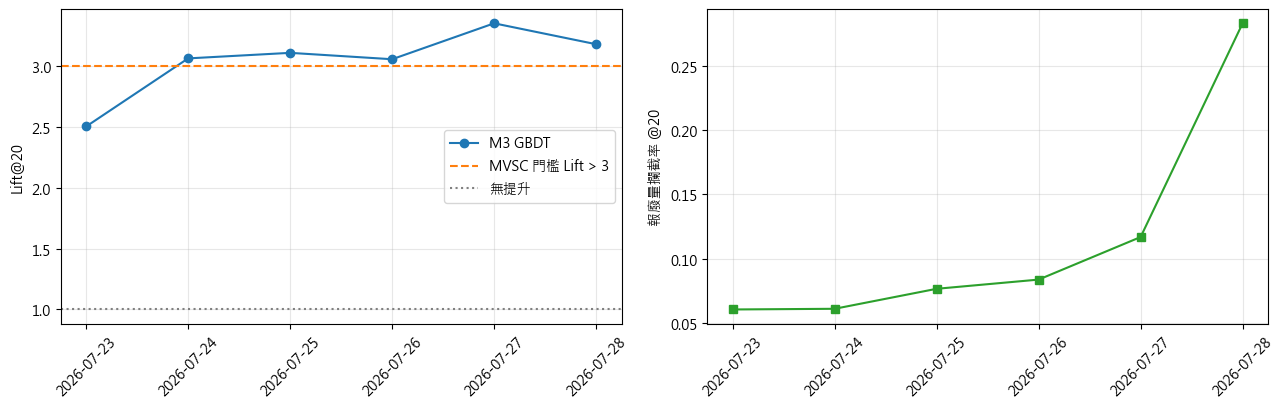

=== MVSC 成功門檻檢核 ===
平均報廢量攔截率 @20：11.4%
Top 20 佔當日批數    ：1.9%
體積 Lift                  ：5.8x   （門檻 > 5）
相對 Champion 的攔截率比值 ：1.41   （門檻 ≥ 1.3）
平均報廢量攔截率               ：11.4%

→ 未達標，維持人工規則；需更長期間資料再評估


In [20]:
if not wf.empty:
    best = wf[wf.model == "M3 GBDT"].sort_values("date")
    ch   = wf[wf.model == CHAMPION].set_index("date")["P_at_K"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].plot(best.date.astype(str), best.Lift_at_K, marker="o", label="M3 GBDT")
    axes[0].axhline(3.0, color="C1", ls="--", label="MVSC 門檻 Lift > 3")
    axes[0].axhline(1.0, color="grey", ls=":", label="無提升")
    axes[0].set_ylabel(f"Lift@{K_PER_DAY}"); axes[0].legend(); axes[0].grid(alpha=.3)
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(best.date.astype(str), best.LossCap_at_K, marker="s", color="C2")
    axes[1].set_ylabel(f"報廢量攔截率 @{K_PER_DAY}"); axes[1].grid(alpha=.3)
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

    common = best.set_index("date").index.intersection(ch.index)
    mean_lift = best.Lift_at_K.mean()
    ratio = (best.set_index("date").loc[common,"P_at_K"] / ch[common].replace(0, np.nan)).mean()

    print("=== MVSC 成功門檻檢核 ===")  
    lc = best.LossCap_at_K.mean()
    k_share = K_PER_DAY / best.n_test.mean()          # Top K 佔當日的比例
    print(f"平均報廢量攔截率 @{K_PER_DAY}：{lc:.1%}")
    print(f"Top {K_PER_DAY} 佔當日批數    ：{k_share:.1%}")
    print(f"體積 Lift                  ：{lc/k_share:.1f}x   （門檻 > 5）")
    chl = wf[wf.model == CHAMPION].set_index("date")["LossCap_at_K"]
    ratio_lc = (best.set_index("date").loc[common,"LossCap_at_K"]
                / chl[common].replace(0, np.nan)).mean()
    print(f"相對 Champion 的攔截率比值 ：{ratio_lc:.2f}   （門檻 ≥ 1.3）")
    print(f"平均報廢量攔截率               ：{best.LossCap_at_K.mean():.1%}")
    print("\n→", "達標，可進入 Shadow Mode 試運行"
          if (mean_lift > 3 and ratio >= 1.5)
          else "未達標，維持人工規則；需更長期間資料再評估")